# Dynamics

Everything so far has been a static calculation: put the atoms somewhere, find
the nearest minimum, read a number off it. Temperature is not in that picture at
all, and a great deal of what a material does is temperature.

Molecular dynamics is the alternative — integrate the equations of motion and
watch. It gives you the things a minimisation cannot: thermal expansion, the
diffusion coefficient without assuming a mechanism, the structure of a liquid,
and an amorphous solid you could not have built by hand.

It is also the part of the pipeline where it is easiest to produce a confident
number from a simulation that never equilibrated.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.71   🧮 Functions: 207   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Loading a dataset

Copper, in a 2×2×2 supercell. Cell size matters more here than anywhere else: a
four-atom cell has no room for a fluctuation, and the periodic images of an atom
are its own nearest neighbours.

In [2]:
copper = mv.datasets.metals(["Cu"], supercell=(2, 2, 2))
mv.pp.describe(copper)

copper.obs[["name", "nsites", "volume", "density"]].round(3)

,name,nsites,volume,density
0,Cu,32,377.902,8.935


## Running

`mv.md.run` integrates in the NVT ensemble by default, with a Langevin
thermostat.

In [3]:
mv.md.run(copper, level="emt", temperature=300.0, steps=2000,
          equilibration=500, timestep=2.0, sample_every=10)

copper.obs[["md_temperature_emt", "md_energy_emt", "md_volume_emt",
            "msd_emt", "diffusivity_emt"]].round(6)

,md_temperature_emt,md_energy_emt,md_volume_emt,msd_emt,diffusivity_emt
0,296.847061,1.06159,377.901704,0.031474,0.0


`md_temperature_emt` is the temperature the run actually achieved, and it is
worth comparing against the 300 K that was asked for every single time.

```{warning}
This check exists because it caught a real failure. With a weaker thermostat and
a shorter equilibration, a run asking for 300 K settled at **69 K** — and every
property computed from it was a property of a 69 K solid, reported as 300 K.
Nothing raised.

`mv.md.run` now warns when the achieved temperature misses the target by more
than 20%, and the defaults are the ones that pass. A thermostat that has not
equilibrated is the single most common way to get a confident wrong answer out
of molecular dynamics.
```

The trajectory is sampled rather than kept whole — one frame per `sample_every`
steps, deposited as a curve on the shared grid.

In [4]:
mv.grid_of(copper, "md_temperature_trace").shape, \
    copper.obsm["md_temperature_trace_emt"].shape

((200,), (1, 200))

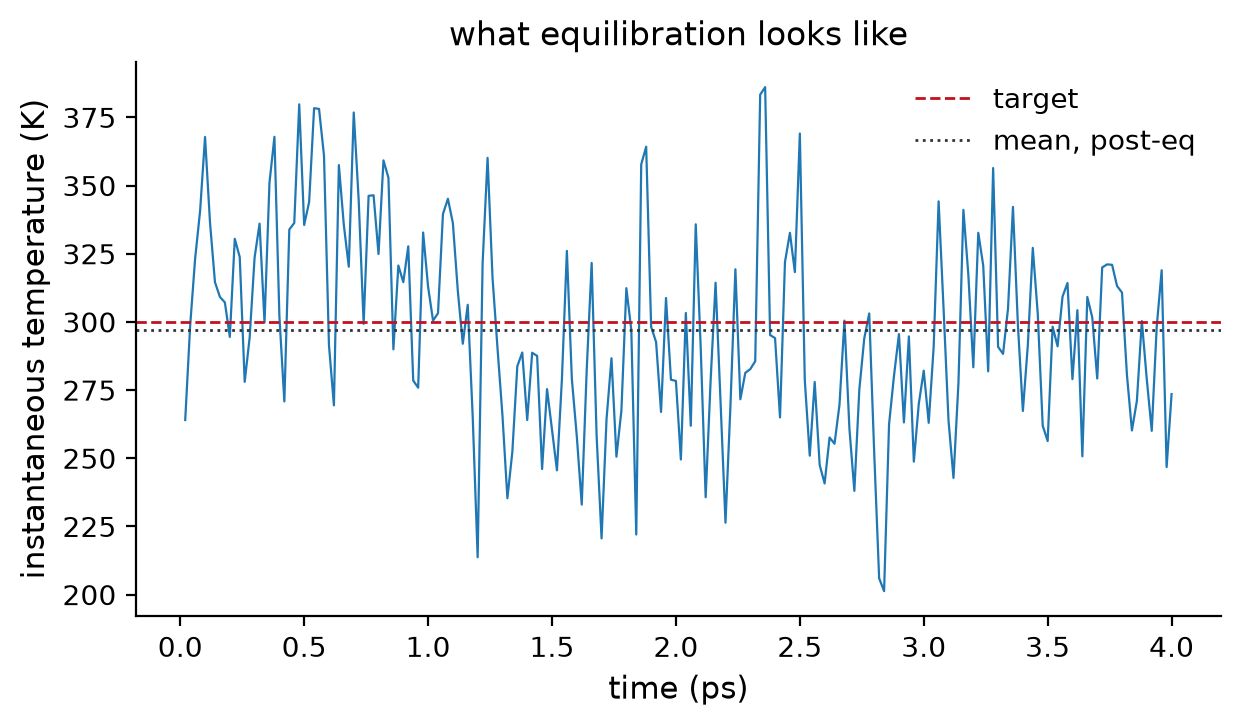

In [5]:
import matplotlib.pyplot as plt

time = mv.grid_of(copper, "md_temperature_trace")
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(time, copper.obsm["md_temperature_trace_emt"][0], linewidth=0.8)
ax.axhline(300, linestyle="--", color="#c1121f", linewidth=1.0,
           label="target")
ax.axhline(float(copper.obs["md_temperature_emt"].iloc[0]),
           linestyle=":", color="#333", linewidth=1.0, label="mean, post-eq")
ax.set_xlabel("time (ps)")
ax.set_ylabel("instantaneous temperature (K)")
ax.set_title("what equilibration looks like")
ax.legend()

The instantaneous temperature swings wildly around its mean, and that is
correct: temperature is defined for an ensemble, and a 32-atom cell is a small
one. Relative fluctuations go as `1/√N`, so this trace is telling you the system
size as much as the thermostat.

What matters is that the mean is flat after equilibration. A trace still
drifting at the end has not equilibrated no matter what the mean says.

## Thermal expansion

Run the same cell at several temperatures and the volume moves — which is the
one property that a fixed-cell minimisation is structurally incapable of
producing.

In [6]:
mv.md.sweep(copper, level="emt", temperatures=(300.0, 600.0, 900.0),
            steps=1200, ensemble="npt", equilibration=400)

pd.DataFrame({"T (K)": mv.grid_of(copper, "md_volume"),
              "volume (A^3)": copper.obsm["md_volume_emt"][0],
              "energy (eV)": copper.obsm["md_energy_emt"][0]}).round(3)

,T (K),volume (A^3),energy (eV)
0,300.0,377.902,1.070
1,600.0,377.902,2.289
2,900.0,377.903,3.493


Text(0.5, 1.0, 'thermal expansion, from motion alone')

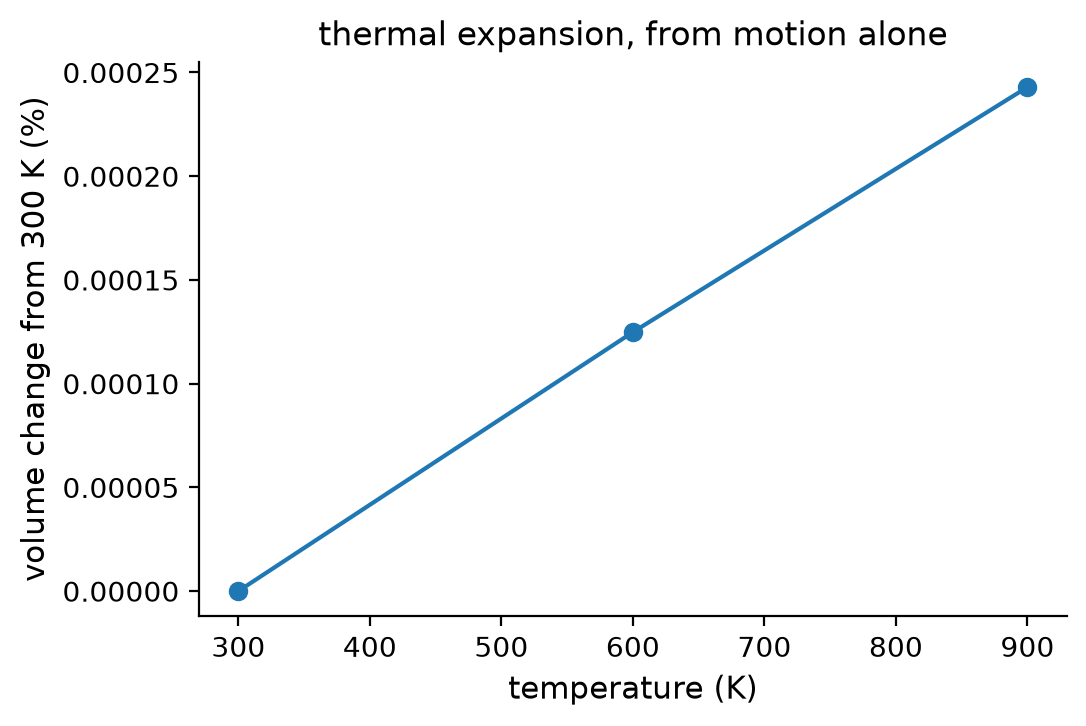

In [7]:
temperature = mv.grid_of(copper, "md_volume")
volume = copper.obsm["md_volume_emt"][0]

fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.plot(temperature, 100 * (volume / volume[0] - 1), "o-")
ax.set_xlabel("temperature (K)")
ax.set_ylabel("volume change from 300 K (%)")
ax.set_title("thermal expansion, from motion alone")

A percent or so over 600 K, which is the right order for a metal — copper's
volumetric expansion coefficient is about 5×10⁻⁵ per K, so 600 K should give
roughly 3%. Nothing about the potential was told to do this; it falls out of the
anharmonicity of the interatomic potential, which is exactly what thermal
expansion is.

## Diffusion, the other way

[Defects and diffusion](defects_and_diffusion.ipynb) got a diffusion
coefficient by computing a barrier and assuming a hopping mechanism. MD gets one
by watching, and the two disagreeing is informative.

The mean squared displacement is what you watch.

In [8]:
mv.md.run(copper, level="emt", temperature=300.0, steps=2000,
          equilibration=500, sample_every=10)
mv.md.conductivity(copper, species="Cu", charge=1.0, level="emt")

copper.obs[["msd_emt", "diffusivity_emt", "conductivity_Cu_emt"]].round(8)

,msd_emt,diffusivity_emt,conductivity_Cu_emt
0,0.031474,0.0,0.0


Essentially zero, and that is the right answer. Copper at 300 K has a vacancy
fraction of about 10⁻²¹ — in a 32-atom cell over 2000 steps there is nothing to
diffuse *through*, so no atom leaves its site.

That is the honest limitation of MD for diffusion in a good crystal: the process
you want to measure happens on a timescale of years, and you have picoseconds.
The barrier calculation in the other tutorial exists precisely because of this.

```{note}
Where MD *does* win is superionic conductors, where the mobile species has no
barrier worth the name and diffuses on a picosecond timescale — Li₁₀GeP₂S₁₂ in
`mv.datasets.load('solid_electrolytes')` is the standard case. That needs a
potential parameterised for Li, Ge, P and S, which EMT is not.
```

### Running many cells at once

Everything above integrates one structure at a time, which wastes a GPU. A
batched engine steps hundreds of independent cells in one kernel call, and the
one worth having is [TorchSim](https://github.com/Radical-AI/torch-sim).

In [9]:
mv.md.batched_available()

{'torch_sim': True, 'cuda': True, 'devices': 1, 'models': {}}

Empty in this build, because the engine is not installed. Registering one is the
same contract as `mv.calc.register_calculator` — a name, a factory that is not
called until the level is used, and the provenance that travels with it:

In [10]:
def torchsim_factory():
    "Imported only when someone actually runs at this level."
    import torch_sim as ts
    return ts.integrate

mv.md.register_batched("torchsim", torchsim_factory,
                       method="TorchSim NVT", license="Apache-2.0")

mv.md.batched_available()["models"]

{'torchsim': {'kind': 'mlip',
  'method': 'TorchSim NVT',
  'reference': None,
  'surrogate': True,
  'license': 'Apache-2.0',
  'uncertainty': None,
  'engine': 'torchsim'}}

The factory is lazy, which is why that cell runs in an environment without
TorchSim installed: registering a level is a promise, and the import only has
to hold when someone runs at that level.

```python
mv.md.run(md, level="torchsim", temperature=300.0, steps=10000)
```

Nothing else in the pipeline changes, because the engine is a level of theory
and `mv.md.run` dispatches on it.

## Melting and quenching

Heat until it melts, cool fast, and you get a glass. This is how amorphous
models are made, and it is a protocol with a known failure mode.

In [11]:
mv.md.melt_quench(copper, level="emt", melt_temperature=2500.0,
                  final_temperature=300.0, melt_steps=600, quench_steps=600,
                  equilibrate_steps=300, supercell=(2, 2, 2))

copper.obs[["amorphous_density_emt", "amorphous_density_ratio_emt"]].round(4)

,amorphous_density_emt,amorphous_density_ratio_emt
0,8.9353,1.0


In [12]:
mv.variants(copper)

['input', 'md_emt', 'amorphous_emt']

```{warning}
A 2026 study found that **every one of eight universal machine-learned
potentials** produced catastrophically under-dense amorphous structures under a
naive NPT quench — densities off by tens of percent, from models that score well
on every static benchmark.

So `melt_quench` quenches at fixed volume by default and **records which
protocol ran**, and it reports `amorphous_density_ratio` next to the density.
A ratio far from 1 means the quench failed, not that you discovered a low-density
phase.
```

In [13]:
mv.level_info(copper, "emt")["protocol"]

'NVT quench then NPT equilibration'

## Was it actually amorphous?

The claim needs checking, and the radial distribution function is how. A crystal
has sharp peaks at well-defined shells; a glass has a first peak and then
structure that washes out.

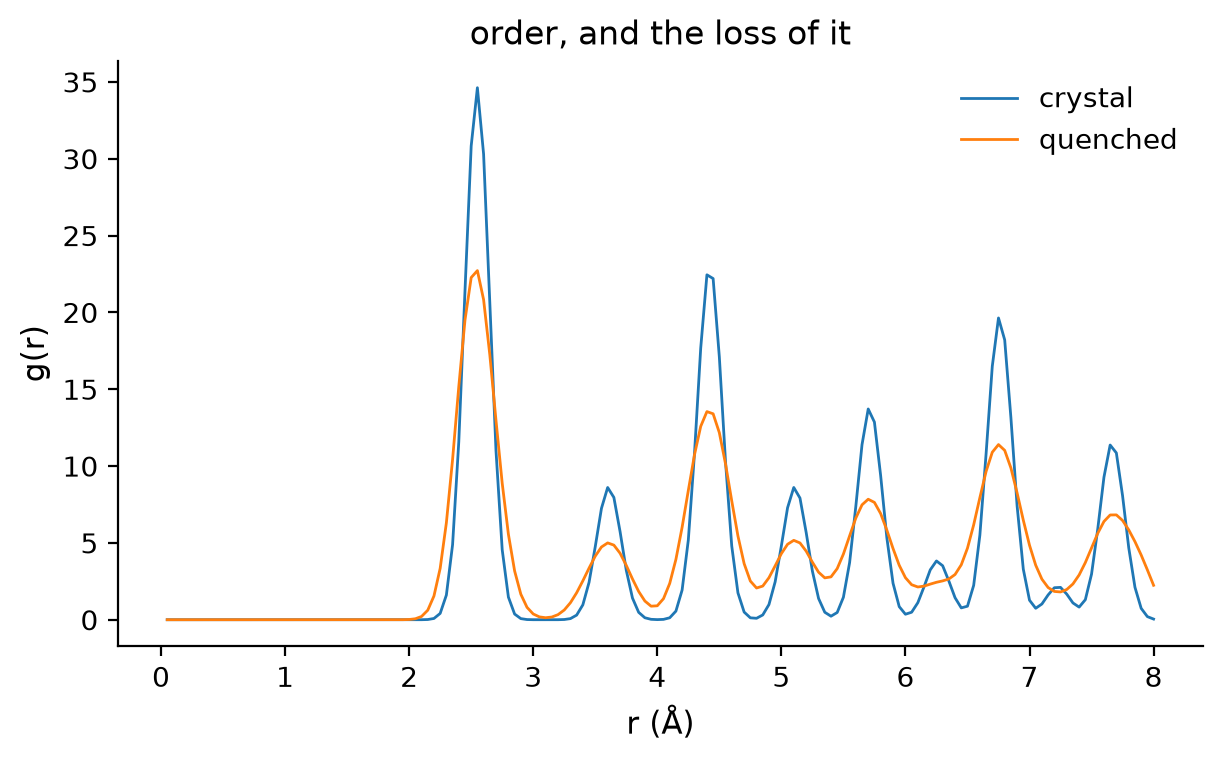

In [14]:
crystal = mv.datasets.metals(["Cu"], supercell=(2, 2, 2))
mv.pp.describe(crystal)
mv.prop.rdf(crystal, r_max=8.0)
mv.prop.rdf(copper, source="amorphous_emt", r_max=8.0, level="amorphous")

r = mv.grid_of(copper, "rdf")
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(r, crystal.obsm["rdf_calc"][0], linewidth=1.0, label="crystal")
ax.plot(r, copper.obsm["rdf_amorphous"][0], linewidth=1.0, label="quenched")
ax.set_xlabel("r (Å)")
ax.set_ylabel("g(r)")
ax.set_title("order, and the loss of it")
ax.legend()

The crystal's shells stay sharp out to 8 Å. The quenched structure keeps its
first-neighbour peak — atoms still have the right number of neighbours at the
right distance, because that is set by the potential — and loses everything
beyond it. Short-range order without long-range order is the definition of a
glass, and this is what it looks like as a measurement.

## What the object remembers

In [15]:
for step in mv.provenance(copper):
    print(step)

data.from_structures
pp.describe(source='input')
md.run(level='emt', source='input', temperature=300.0, steps=2000, ensemble='nvt')
md.sweep(level='emt', source='input', temperatures=[300.0, 600.0, 900.0], ensemble='npt')
md.run(level='emt', source='input', temperature=300.0, steps=2000, ensemble='nvt')
md.conductivity(species='Cu', charge=1.0, level='emt', temperature=296.84706071763)
md.melt_quench(level='emt', source='input', melt_temperature=2500.0, fixed_volume_quench=True)
prop.rdf(source='amorphous_emt', level='amorphous', r_max=8.0, sigma=0.1)


Every temperature, every step count, every thermostat setting. For MD that is
not bookkeeping — the numbers above are only interpretable next to the protocol
that produced them, and a trajectory whose thermostat you cannot recover is a
trajectory you cannot defend.

```{seealso}
[Defects and diffusion](defects_and_diffusion.ipynb) reaches diffusion by the
static route, and explains why the two are complementary rather than redundant.
```

## Where the atoms spend their time

`mv.prop.rdf` takes one static structure and reports where the atoms *are*.
`mv.md.rdf` takes a trajectory and reports where they **spend their time**. For
a crystal near 0 K the two converge; for a liquid, a superionic conductor, or
anything above half its melting point they do not — and that difference is the
thermal broadening that makes a measured diffraction pattern wider than a
simulated one.

The trajectory is an argument, because `mv.md.run` deliberately does not keep
one: a screening library that materialised every frame would spend its memory on
positions nobody reads.

In [16]:
from pymatgen.core import Lattice, Structure

cell = Structure(Lattice.cubic(4.2), ["Li", "Cl", "Cl", "Cl"],
                 [[0, 0, 0], [.5, .5, 0], [.5, 0, .5], [0, .5, .5]])
one = mv.data.from_structures([cell])
mv.pp.describe(one)

# Stand-in for a real trajectory: the same cell, jittered over 40 frames.
frames = np.tile(np.array(cell.frac_coords), (40, 1, 1))
frames = frames + np.random.default_rng(0).normal(0, 0.01, frames.shape)

try:
    mv.md.rdf(one, frames, species="Li", r_max=8.0)
    result = one.obs[["formula", "first_shell_md",
                      "first_shell_coordination_md"]].round(3)
except ImportError as exc:
    result = str(exc)          # pymatgen-analysis-diffusion is an extra
result

,formula,first_shell_md,first_shell_coordination_md
0,LiCl3,2.96,11.692


The first peak lands at 2.96 Å against a nearest-neighbour distance of 2.97, and
the coordination number comes out at **11.7 against a true 12** — the shortfall
being the Gaussian smearing spilling past the cutoff.

```{note}
That integral is computed here from its definition,
$n(r) = \int 4\pi r^2 \rho\, g(r)\, dr$, rather than taken from pymatgen's
`coordination_number`, which reports the count **per reference index**. On this
cell — twelve neighbours spread over three reference sites — pymatgen returns
4.0. Four is not a coordination number for that cell, and a column called
`first_shell_coordination` had better be one.
```

## How much of the cell do they visit?

Before either of the next two questions there is a blunter one: how much of the
box do the mobile ions actually go into? Histogram their positions over the run
and the answer is a probability density — tight blobs at the lattice sites for a
normal solid, smeared out along the channels for a superionic conductor.

`mv.md.occupancy` reports it as three scalars. The one to read is
`occupied_fraction`: the fraction of the cell holding 90% of the probability.

In [17]:
occ = mv.data.from_structures([Structure(
    Lattice.cubic(5.0), ["Li"] * 4,
    [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])])
sites_base = np.array(mv.structures(occ, "input")[0].frac_coords)
gen = np.random.default_rng(0)

runs = {
    "frozen": sites_base[None].repeat(400, axis=0),
    "tight": (sites_base[None] + gen.normal(0, 0.01, (400, 4, 3))) % 1.0,
    "floppy": (sites_base[None] + gen.normal(0, 0.05, (400, 4, 3))) % 1.0,
    "liquid": gen.random((4000, 4, 3)),
}
for label, traj in runs.items():
    mv.md.occupancy(occ, traj, species="Li", bins=8, key_added=label)

occ.obs[[f"occupied_fraction_{k}" for k in runs]
        + [f"occupancy_entropy_{k}" for k in runs]].round(4).T

,0
occupied_fraction_frozen,0.0078
occupied_fraction_tight,0.0566
occupied_fraction_floppy,0.0586
occupied_fraction_liquid,0.8652
occupancy_entropy_frozen,0.2222
occupancy_entropy_tight,0.5541
occupancy_entropy_floppy,0.5850
occupancy_entropy_liquid,0.9977


Monotonic, from four ions pinned in four voxels to a liquid that has forgotten
where the sites were. The liquid stops at **0.87 rather than 1.0**, which is not
an error: covering 90% of a uniform probability still leaves out the tail of
voxels that happened to be visited least.

Now the part worth being careful about, because it is the way this number lies.

It is a histogram, so it says something about the material only when there are
enough samples to fill the grid. Ask for a finer grid than the run can populate
and a liquid will report as beautifully localised — not because the ions stayed
put but because most voxels were never visited at all:

In [18]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    mv.md.occupancy(occ, gen.random((100, 4, 3)), species="Li", bins=24,
                    key_added="undersampled")

print(f"same uniform distribution, finer grid: "
      f"{float(occ.obs['occupied_fraction_undersampled'].iloc[0]):.3f}")
print(f"samples per voxel: "
      f"{occ.uns['occupancy']['undersampled']['samples_per_voxel'][0]:.2f}")
print(str(caught[-1].message)[:160] if caught else "no warning")

same uniform distribution, finer grid: 0.026
samples per voxel: 0.03
row 0: 400 sampled positions over 13824 voxels is 0.03 per voxel. Below about five, most voxels are empty because the run was short rather than because the ions


0.87 became 0.03 with no change to the physics. That is why the function warns
below about five samples per voxel and records the sampling density in `uns`
rather than handing back the number quietly.

The practical consequence: **compare these values between runs of the same
length on the same grid.** Across different ones they are not comparable, and no
normalisation makes them so.

## The shape of the motion

A diffusivity is one number and it averages over everything. The van Hove
correlation function keeps the shape.

Its **self** part is the distribution of how far one atom moved in a time `dt`.
Its **distinct** part is where the *other* atoms were relative to it — and at
`dt = 0` that is exactly the radial distribution function, which is the identity
worth checking rather than trusting.

In [19]:
from pymatgen.core import Lattice, Structure

salt = Structure(Lattice.cubic(4.2), ["Li", "Cl", "Cl", "Cl"],
                 [[0, 0, 0], [.5, .5, 0], [.5, 0, .5], [0, .5, .5]])
salt.make_supercell([3, 3, 3])
vh = mv.data.from_structures([salt])
coords = np.array(salt.frac_coords)

mv.md.van_hove(vh, coords[None].repeat(3, axis=0), dt=0, r_max=8.0,
               n_grid=401, sigma=0.05, level="static")

r = mv.grid_of(vh, "van_hove_distinct")
g_d = vh.obsm["van_hove_distinct_static"][0]
rho = len(salt) / salt.lattice.volume

# int 4 pi r^2 rho G_d dr out to R is the number of neighbours within R
for radius in (3.5, 5.0, 6.5):
    inside = r <= radius
    counted = np.trapezoid(4 * np.pi * r[inside] ** 2 * rho * g_d[inside],
                           r[inside])
    actual = np.mean([len(salt.get_neighbors(s, radius)) for s in salt])
    print(f"R = {radius} A   integral {counted:6.2f}   actual {actual:6.2f}")

R = 3.5 A   integral  12.11   actual  12.00
R = 5.0 A   integral  18.22   actual  18.00
R = 6.5 A   integral  54.54   actual  54.00


Twelve, eighteen, fifty-four — the neighbour counts of a rocksalt lattice,
recovered from the correlation function by integration. The small excess is the
Gaussian smearing spilling past each cutoff, the same effect that puts
`first_shell_coordination` at 11.7 rather than 12 above.

That is what fixes the normalisation. It is easy to write a van Hove function
whose *shape* is right and whose scale is off by a power of r or a factor of N,
and nothing about the plot would tell you.

Now the self part, which is where the interesting shape lives:

In [20]:
rng = np.random.default_rng(0)
wobble = (coords[None] + rng.normal(0, 0.01, (20, len(salt), 3))) % 1.0

# and the same thing with six ions displaced by one nearest-neighbour vector
jumped = wobble.copy()
jumped[10:, :6, :] = (wobble[10:, :6, :] + np.array([.5, .5, 0]) / 3) % 1.0

mv.md.van_hove(vh, wobble, dt=15, r_max=8.0, n_grid=401, sigma=0.1,
               level="rattling")
mv.md.van_hove(vh, jumped, dt=15, r_max=8.0, n_grid=401, sigma=0.1,
               level="hopping")

vh.obs[["van_hove_rms_rattling", "van_hove_peak_rattling",
        "van_hove_jump_rattling", "van_hove_rms_hopping",
        "van_hove_peak_hopping", "van_hove_jump_hopping"]].round(3)

,van_hove_rms_rattling,van_hove_peak_rattling,van_hove_jump_rattling,van_hove_rms_hopping,van_hove_peak_hopping,van_hove_jump_hopping
0,0.309,0.28,NaN,0.781,0.28,3.02


Two things to read.

`van_hove_peak` is the **most probable** displacement, and it is not zero even
for a solid that only vibrates. A shell at radius $r$ has area $4\pi r^2$, so
the shell volume beats the falling Gaussian and the mode sits near $\sqrt{2}$
times the one-dimensional amplitude. A van Hove function peaking at zero would
mean the $r^2$ weighting had been dropped somewhere.

`van_hove_jump` is the outermost local maximum, and it is **NaN for the
rattling run and 3.0 Å for the hopping one** — the nearest-neighbour distance
of this lattice is $a/\sqrt{2} = 2.97$ Å, and the reported value sits one grid
point away because the curve was smeared with $\sigma = 0.1$ Å. Six ions in a hundred and eight moved; they contribute a few
percent of the weight and never come close to outranking the vibrational peak,
which is why this is found by position rather than by height.

That is the distinction a diffusivity cannot draw. Both runs have a raised
mean-squared displacement. Only one of them is transport.

## Rattling or hopping?

Both raise the mean-squared displacement, and only one of them is diffusion. An
MSD cannot separate an ion vibrating harder in the same well from an ion moving
between wells — it reports the same larger number either way.

`mv.md.sites` clusters the sampled positions instead, so the two come apart.
`md_site_spread` is the RMS distance from a position to the centre of its own
site, in ångströms, which is a thermal vibration amplitude.
`md_site_visits` is the mean number of distinct sites one atom was found at:
**1.0 means nothing hopped.**

In [21]:
from pymatgen.core import Lattice, Structure

# Four lithium on an fcc lattice, so there are four sites to be found and
# four ions to find them. The LiCl cell above has a single Li, which cannot
# show the difference between one ion hopping and none.
sites_cell = Structure(Lattice.cubic(5.0), ["Li"] * 4,
                       [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])
four = mv.data.from_structures([sites_cell])

base = np.array(sites_cell.frac_coords)
rng = np.random.default_rng(0)
still = (base[None] + rng.normal(0, 0.01, (40, 4, 3))) % 1.0

# Move one ion to a neighbouring site half way through the run, and change
# nothing else — same cell, same vibration amplitude, one hop.
hopped = still.copy()
hopped[20:, 0, :] = base[1] + rng.normal(0, 0.01, (20, 3))

try:
    mv.md.sites(four, still, species="Li", key_added="still")
    mv.md.sites(four, hopped % 1.0, species="Li", key_added="hopped")
    result = four.obs[["md_sites_still", "md_site_spread_still",
                       "md_site_visits_still", "md_sites_hopped",
                       "md_site_spread_hopped",
                       "md_site_visits_hopped"]].round(3)
except ImportError as exc:
    result = str(exc)          # pymatgen-analysis-diffusion is an extra
result

,md_sites_still,md_site_spread_still,md_site_visits_still,md_sites_hopped,md_site_spread_hopped,md_site_visits_hopped
0,4,0.086,1.0,4,0.086,1.25


The vibration amplitude is unchanged between the two runs, because it *is*
unchanged — the same noise was added to both. What moved is the visit count, and
it moved by exactly the amount it should: one ion of four found two sites
instead of one, so the mean over four ions is (2+1+1+1)/4 = **1.25**.

That is the number an MSD cannot give you. Read the two together: a large spread
with visits near 1.0 is a hot, soft, non-conducting solid, and a small spread
with visits above 1.0 is a well-ordered ionic conductor doing its job.

```{note}
`n_sites` defaults to the number of atoms of that species in the cell, which is
right when each ion has its own site and wrong for an interstitial mechanism
where there are more wells than ions. k-means needs the count in advance and
cannot discover it, so it is a parameter rather than a result — if you expect
interstitials, say how many.
```